# Module 3 — Vẽ biểu đồ phân tích dữ liệu điện gió

Notebook đọc dữ liệu sạch `Data/output/du_lieu_sach.csv` và vẽ 4 biểu đồ bằng **matplotlib**. Mỗi biểu đồ vừa hiển thị trong notebook, vừa lưu ra file PNG trong folder `Report`.

1. Đường cong công suất (power curve) — tô đỏ điểm nghi sự cố
2. Sản lượng theo tháng + tốc độ gió trung bình (trục y phụ)
3. Phân phối tốc độ gió và công suất (2 histogram)
4. Công suất trung bình theo 8 hướng gió

## Chuẩn bị — Đọc dữ liệu và tạo folder Report

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_INPUT = "../Data/output/du_lieu_sach.csv"
REPORT_DIR = "../Report"

# Tạo folder Report nếu chưa có
os.makedirs(REPORT_DIR, exist_ok=True)

# Đọc dữ liệu sạch; đặt thoi_gian làm chỉ mục thời gian
df = pd.read_csv(CSV_INPUT, index_col="thoi_gian", parse_dates=True)

print(f"Đã đọc {len(df)} dòng dữ liệu.")
print("Các cột:", list(df.columns))
df.head()

Đã đọc 48835 dòng dữ liệu.
Các cột: ['cong_suat_kw', 'toc_do_gio', 'cong_suat_ly_thuyet', 'huong_gio']


,cong_suat_kw,toc_do_gio,cong_suat_ly_thuyet,huong_gio
thoi_gian,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
2018-01-01 00:30:00,419.645904,5.659674,516.127569,271.258087
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


## Biểu đồ 1 — Đường cong công suất (Power Curve)

Biểu đồ phân tán: tốc độ gió (trục X) vs công suất thực (trục Y). Các điểm **nghi sự cố** (gió > 5 m/s nhưng công suất < 50% công suất lý thuyết) được tô **đỏ**.

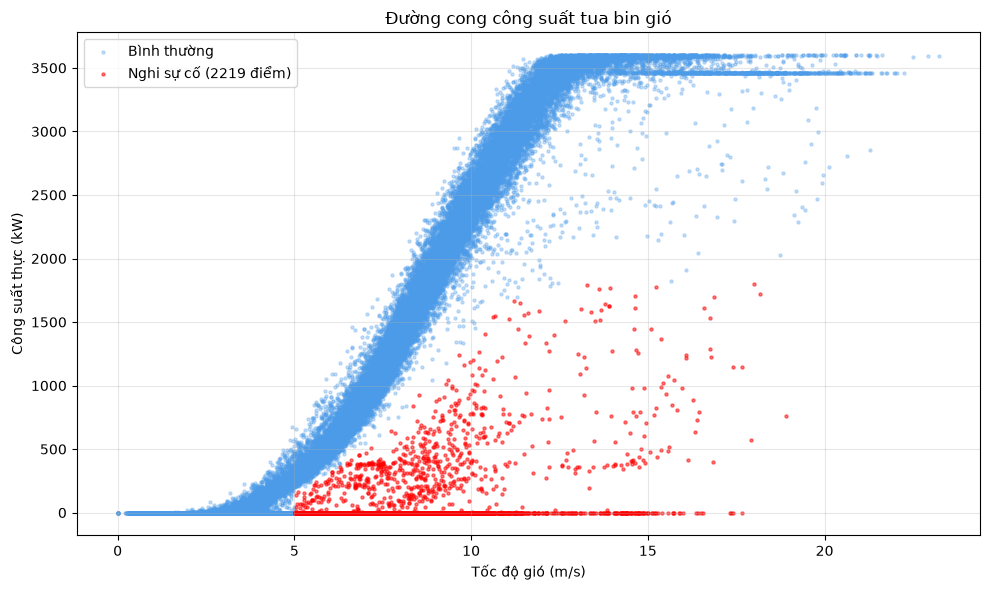

Số điểm nghi sự cố: 2219 (4.54%)


In [ ]:
# Xác định điểm nghi sự cố: gió mạnh nhưng công suất thấp bất thường
nghi_su_co = (df["toc_do_gio"] > 5) & (df["cong_suat_kw"] < 0.5 * df["cong_suat_ly_thuyet"])
binh_thuong = ~nghi_su_co

fig, ax = plt.subplots(figsize=(10, 6))

# Điểm bình thường (xanh) và điểm nghi sự cố (đỏ)
ax.scatter(df.loc[binh_thuong, "toc_do_gio"], df.loc[binh_thuong, "cong_suat_kw"],
           s=5, alpha=0.3, color="#4C9BE8", label="Bình thường")
ax.scatter(df.loc[nghi_su_co, "toc_do_gio"], df.loc[nghi_su_co, "cong_suat_kw"],
           s=5, alpha=0.5, color="red", label=f"Nghi sự cố ({nghi_su_co.sum()} điểm)")

ax.set_title("Đường cong công suất tua bin gió")
ax.set_xlabel("Tốc độ gió (m/s)")
ax.set_ylabel("Công suất thực (kW)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "duong_cong_cong_suat.png"), dpi=120)
plt.show()
print(f"Số điểm nghi sự cố: {nghi_su_co.sum()} ({nghi_su_co.mean()*100:.2f}%)")

**Cách đọc biểu đồ:** Đường cong công suất cho thấy quan hệ giữa tốc độ gió và công suất phát. Bình thường công suất tăng theo hình chữ S: gần 0 khi gió yếu, tăng mạnh ở vùng giữa, rồi bão hòa ở công suất định mức khi gió mạnh. Các **điểm đỏ** nằm thấp bất thường dù gió mạnh (> 5 m/s) là dấu hiệu tua bin dừng, bảo trì hoặc lỗi cảm biến — cần rà soát thêm.

## Biểu đồ 2 — Sản lượng theo tháng + tốc độ gió trung bình

Cột: tổng công suất theo tháng. Đường (trục y phụ): tốc độ gió trung bình mỗi tháng.

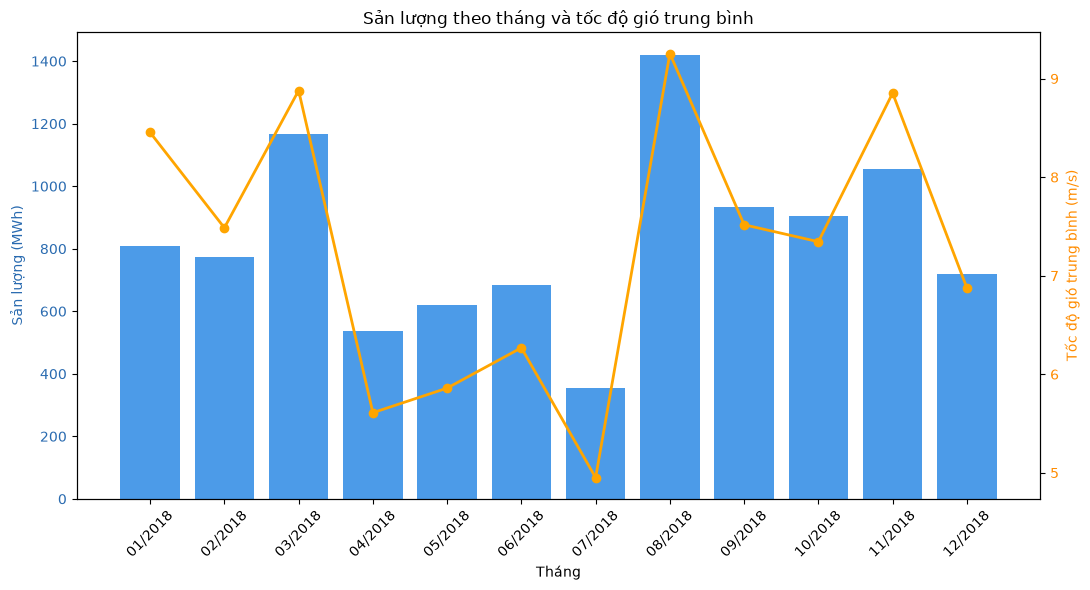

In [ ]:
# Gộp theo tháng: tổng công suất và tốc độ gió trung bình
theo_thang = df.resample("ME").agg(
    tong_cong_suat=("cong_suat_kw", "sum"),
    toc_do_gio_tb=("toc_do_gio", "mean"),
)
nhan_thang = theo_thang.index.strftime("%m/%Y")

fig, ax1 = plt.subplots(figsize=(11, 6))

# Trục chính: cột tổng công suất (đổi sang MWh cho dễ đọc: kW * 10 phút / 60 / 1000)
san_luong_mwh = theo_thang["tong_cong_suat"] * (10 / 60) / 1000
ax1.bar(nhan_thang, san_luong_mwh, color="#4C9BE8", label="Sản lượng (MWh)")
ax1.set_xlabel("Tháng")
ax1.set_ylabel("Sản lượng (MWh)", color="#2A6BB0")
ax1.tick_params(axis="y", labelcolor="#2A6BB0")
ax1.tick_params(axis="x", rotation=45)

# Trục phụ: đường tốc độ gió trung bình
ax2 = ax1.twinx()
ax2.plot(nhan_thang, theo_thang["toc_do_gio_tb"], color="orange",
         marker="o", linewidth=2, label="Tốc độ gió TB (m/s)")
ax2.set_ylabel("Tốc độ gió trung bình (m/s)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax1.set_title("Sản lượng theo tháng và tốc độ gió trung bình")
fig.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "san_luong_thang.png"), dpi=120)
plt.show()

**Cách đọc biểu đồ:** Cột xanh là tổng sản lượng điện mỗi tháng (MWh), đường cam là tốc độ gió trung bình tháng (trục phải). Hai đại lượng thường **đi cùng chiều**: tháng gió mạnh thường cho sản lượng cao. Nếu một tháng gió mạnh nhưng sản lượng lại thấp, đó là dấu hiệu tua bin gặp sự cố hoặc dừng máy nhiều trong tháng đó.

## Biểu đồ 3 — Phân phối tốc độ gió và công suất

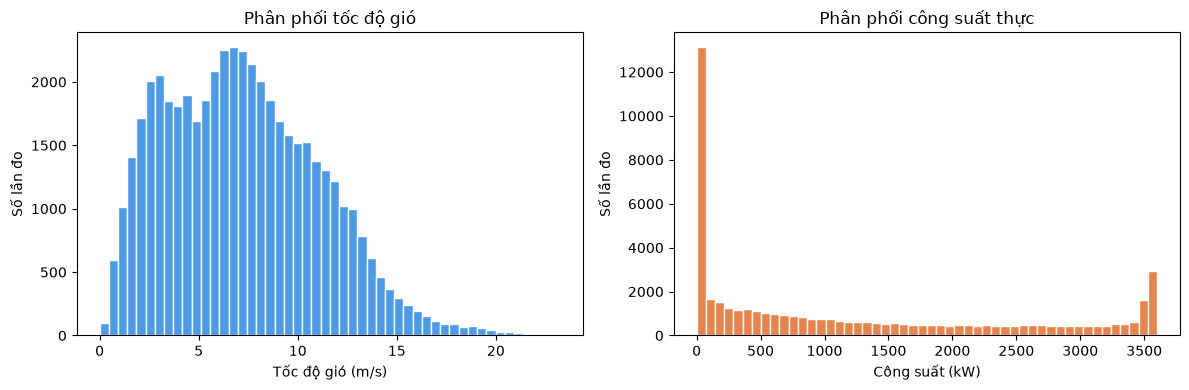

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Phân phối tốc độ gió
axes[0].hist(df["toc_do_gio"], bins=50, color="#4C9BE8", edgecolor="white")
axes[0].set_title("Phân phối tốc độ gió")
axes[0].set_xlabel("Tốc độ gió (m/s)")
axes[0].set_ylabel("Số lần đo")

# Phân phối công suất
axes[1].hist(df["cong_suat_kw"], bins=50, color="#E8834C", edgecolor="white")
axes[1].set_title("Phân phối công suất thực")
axes[1].set_xlabel("Công suất (kW)")
axes[1].set_ylabel("Số lần đo")

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "phan_phoi.png"), dpi=120)
plt.show()

**Cách đọc biểu đồ:** Histogram tốc độ gió thường có dạng lệch phải (phân phối Weibull) — gió trung bình xuất hiện nhiều nhất, gió rất mạnh hiếm. Histogram công suất thường có hai cụm đáng chú ý: một cụm lớn ở **gần 0** (lúc gió yếu hoặc tua bin dừng) và một cụm ở **công suất định mức** (khi gió đủ mạnh để đạt công suất tối đa).

## Biểu đồ 4 — Công suất trung bình theo 8 hướng gió

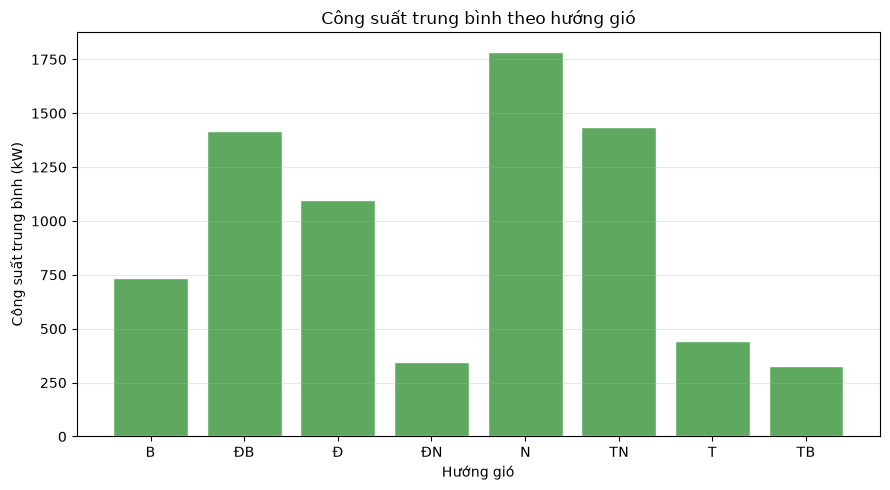

Công suất trung bình (kW) theo hướng:
B      734.2
ĐB    1415.6
Đ     1096.6
ĐN     344.7
N     1786.1
TN    1435.7
T      442.3
TB     325.1
dtype: float64


In [ ]:
# Chia 360 độ thành 8 hướng, mỗi hướng 45 độ. Tâm hướng B lệch -22.5 độ
ten_huong = ["B", "ĐB", "Đ", "ĐN", "N", "TN", "T", "TB"]
# Dịch góc +22.5 để hướng B (Bắc) gom cả vùng quanh 0/360 độ
goc_dich = (df["huong_gio"] + 22.5) % 360
nhom_huong = (goc_dich // 45).astype(int)  # 0..7

# Công suất trung bình theo từng hướng
cs_theo_huong = df.groupby(nhom_huong)["cong_suat_kw"].mean().reindex(range(8))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(ten_huong, cs_theo_huong.values, color="#5FA85F", edgecolor="white")
ax.set_title("Công suất trung bình theo hướng gió")
ax.set_xlabel("Hướng gió")
ax.set_ylabel("Công suất trung bình (kW)")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "huong_gio.png"), dpi=120)
plt.show()
print("Công suất trung bình (kW) theo hướng:")
print(pd.Series(cs_theo_huong.values, index=ten_huong).round(1))

**Cách đọc biểu đồ:** Mỗi cột là công suất trung bình khi gió thổi từ một trong 8 hướng (B = Bắc, ĐB = Đông Bắc, ...). Hướng có cột cao là **hướng gió chủ đạo** — mang lại nhiều năng lượng nhất cho tua bin. Thông tin này hữu ích để đánh giá vị trí đặt tua bin và định hướng vận hành. (Lưu ý: đây là công suất trung bình, chưa tính số lần gió thổi từ mỗi hướng.)